### Opis danych w tabelach (Kolumny 0-6)

Dane pochodzą z bazy nagrań Holtera i mają postać szeregów czasowych RR (czasów pomiędzy kolejnymi skurczami serca). Są to dane nierównomiernie próbkowane, odzwierciedlające regulację układu autonomicznego.

**Struktura kolumn w tablicach `chf_array` oraz `nsr_array`:**

* **Kolumna 0 (`n_intervals`):** Liczba interwałów RR w całym nagraniu.
* **Kolumna 1 (`mean_RR`):** Średni RR – średnia długość odstępu między skurczami.
* **Kolumna 2 (`std_RR`):** Odchylenie standardowe RR – podstawowa miara zmienności rytmu serca (HRV).
* **Kolumna 3 (`n_windows`):** Liczba okien (fragmentów), na które podzielono nagranie do analizy.
* **Kolumna 4 (`ApEn`):** Approximate Entropy (Entropia przybliżona) – miara nieliniowa określająca złożoność i przewidywalność sygnału.
* **Kolumna 5 (`SampEn`):** Sample Entropy (Entropia próbkowania) – udoskonalona miara nieliniowa, mniej zależna od długości szeregu czasowego.
* **Kolumna 6 (`Shannon`):** Entropia Shannona – miara stopnia nieuporządkowania danych.

In [2]:
import pandas as pd
import numpy as np

#Wczytanie jako tabele
chf_df = pd.read_csv('chf.csv')
nsr_df = pd.read_csv('nsr.csv')

#Konwersja na tablice numpy
# Usunięcie kolumny z file_name
chf_array = chf_df.drop(columns=['file_name']).to_numpy()
nsr_array = nsr_df.drop(columns=['file_name']).to_numpy()

# Sprawdzenie wymiarów
print(f"Tablica CHF ma rozmiar: {chf_array.shape}") # (wiersze, kolumny)
print(f"Tablica NSR ma rozmiar: {nsr_array.shape}")

Tablica CHF ma rozmiar: (29, 7)
Tablica NSR ma rozmiar: (54, 7)


**Poniższy kod przygotowuje zmienne (np. chf_mean, nsr_std), które są gotowymi wektorami statystyk.**

In [3]:
# 2. Obliczenia dla grupy CHF
chf_mean   = np.mean(chf_array, axis=0)   # Średnia
chf_median = np.median(chf_array, axis=0) # Mediana
chf_std    = np.std(chf_array, axis=0, ddof=1) # Odchylenie standardowe (ddof=1 daje wynik jak w Excelu/Pandas)

# 3. Obliczenia dla grupy NSR
nsr_mean   = np.mean(nsr_array, axis=0)
nsr_median = np.median(nsr_array, axis=0)
nsr_std    = np.std(nsr_array, axis=0, ddof=1)

# 4. Wyświetlenie wyników (przykład dla pierwszej cechy, czyli n_intervals)
print(f"Statystyki dla pierwszej kolumny (n_intervals) w grupie CHF:")
print(f"Średnia: {chf_mean[0]:.2f}, Mediana: {chf_median[0]:.2f}, Odchylenie: {chf_std[0]:.2f}")

Statystyki dla pierwszej kolumny (n_intervals) w grupie CHF:
Średnia: 107155.07, Mediana: 102645.00, Odchylenie: 19899.65


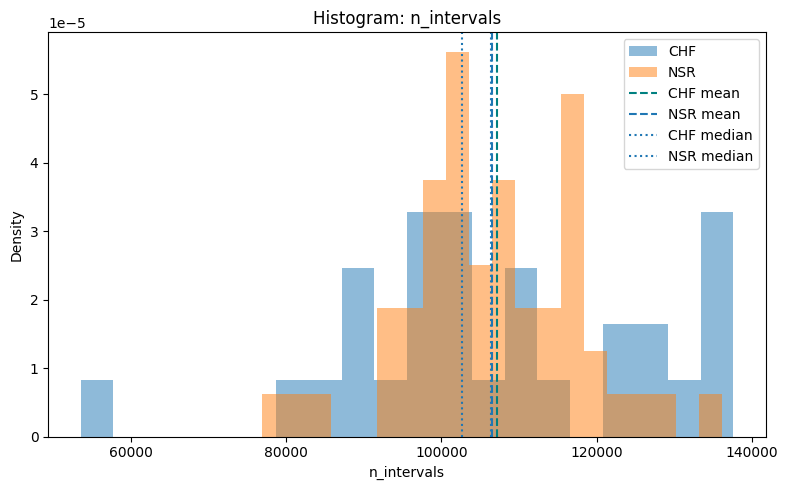

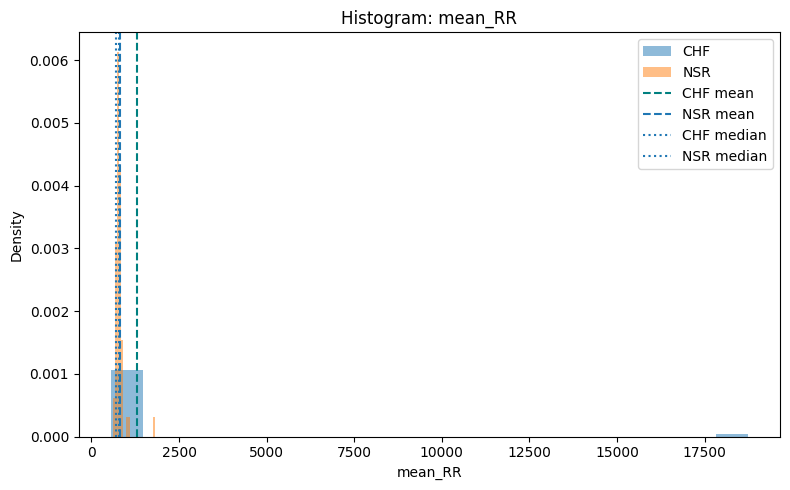

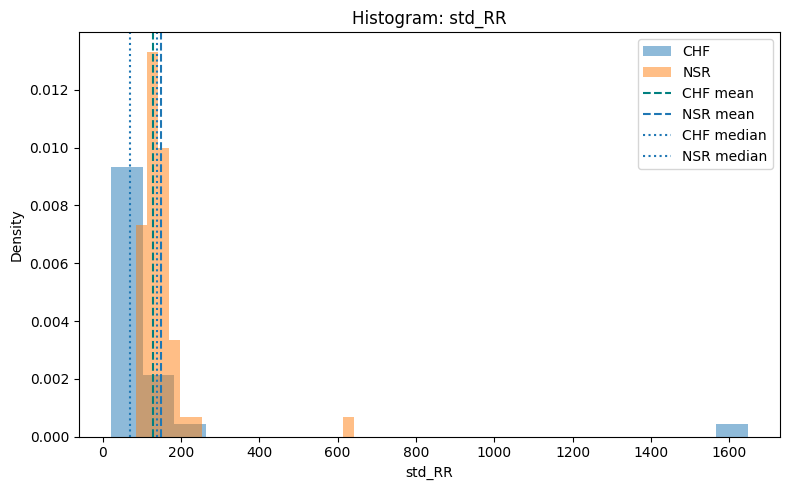

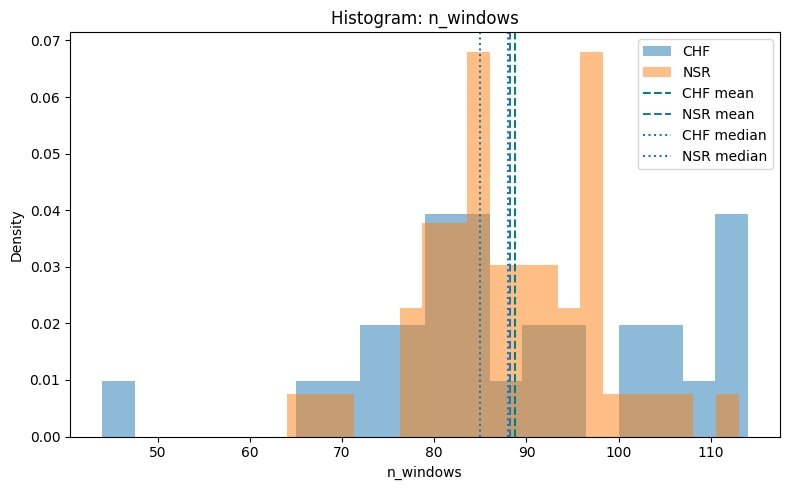

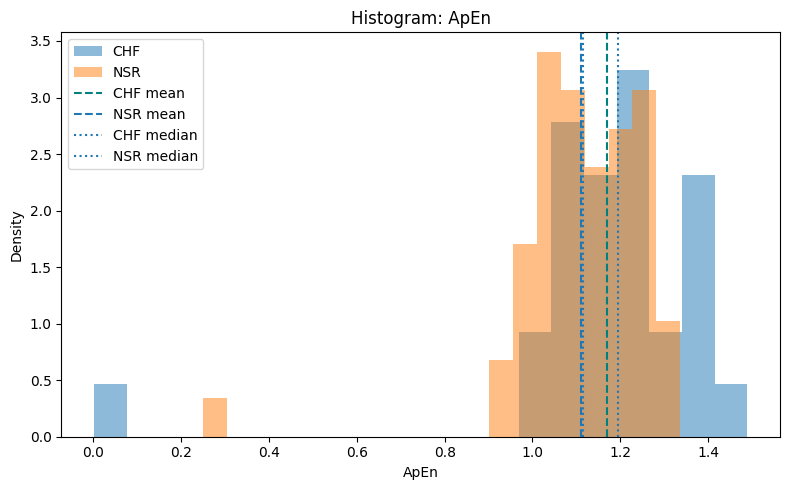

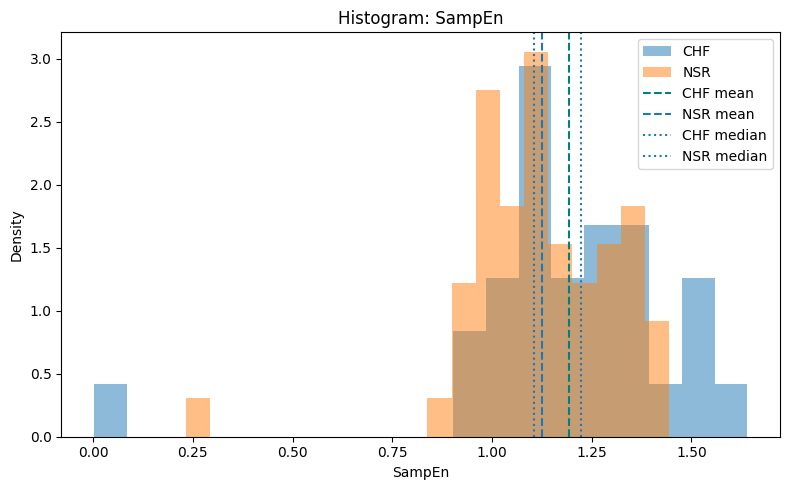

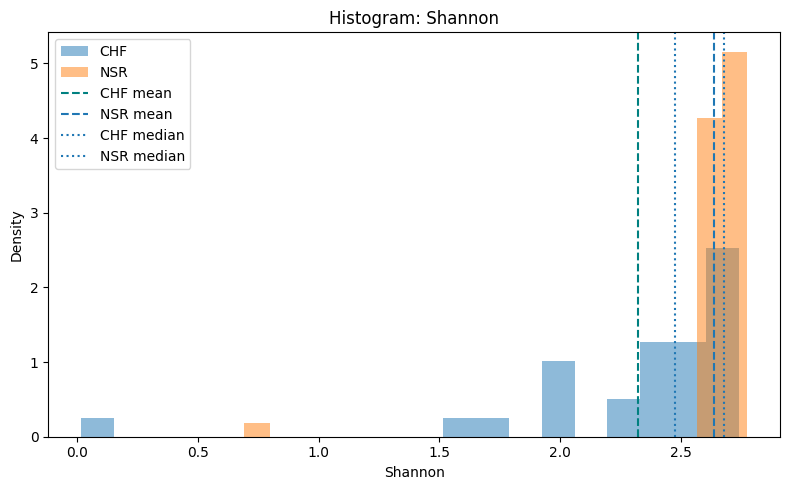

IndexError: index 7 is out of bounds for axis 1 with size 7

<Figure size 800x500 with 0 Axes>

In [ ]:
# Histogramy (pomijamy pierwszą kolumnę)

for i, col in enumerate(chf_df.columns[1:], start=1):

    plt.figure(figsize=(8,5))

    plt.hist(
        chf_array[:, i],
        bins=20,
        alpha=0.5,
        density=True,
        label="CHF"
    )

    plt.hist(
        nsr_array[:, i-1],
        bins=20,
        alpha=0.5,
        density=True,
        label="NSR"
    )

    # Średnie
    plt.axvline(chf_mean[i-1], linestyle='--',color='teal', label='CHF mean')
    plt.axvline(nsr_mean[i-1], linestyle='--', label='NSR mean')

    # Mediany
    plt.axvline(chf_median[i-1], linestyle=':', label='CHF median')
    plt.axvline(nsr_median[i-1], linestyle=':', label='NSR median')

    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()

    plt.tight_layout()
    plt.show()